# Building an Uncertainty Budget - `ODR` version using x- and y-uncertainties

V1.1: Mar 10, 2026

## 1. Motivation

When you are looking to iterate and improve on an experiment, you need to ask yourself how much does the uncertainty in each of your measurements contribute to the uncertainty in your final result? If you could improve one thing about your measurement approach, which would help most? An Uncertainty Budget can help answer that. We use a mass-on-a-spring system for this example, but the approach works for any experiment where you extract a parameter from a fit.

## 2. The approach for estimating contributions to your overall uncertainty budget

For each uncertainty source we ask "what would happen if this measurement were twice as imprecise?" To do this, we double that source's uncertainty, repeat the fit, and then record how much the output uncertainty grows. This allows us to determine how much that uncertainty source contributed to the uncertainty in the final result, $\delta k$.

Let's look at this in more detail. Since independent uncertainty sources add in quadrature, we can write:

$$\delta k_{\text{full}}^2 = \text{impact}_1^2 + \text{impact}_2^2 + \cdots.$$

And then when fitting, each source's contribution to $\delta k$ scales linearly with its input uncertainty (see note below): double $\sigma_i$, and $\text{impact}_i$ doubles. Doubling source $\sigma_i$ therefore replaces $\text{impact}_i^2$ with $(2\,\text{impact}_i)^2 = 4\,\text{impact}_i^2$ in the sum, leaving all other terms unchanged:

$$\delta k_{\text{doubled}}^2 = \delta k_{\text{full}}^2 + 3\,\text{impact}_i^2.$$

Here $3 = 4 - 1$: the doubled term grew by a factor of 4, so the net increase of $\delta k$ over the baseline is 3 times the original contribution. Solving for the impact gives

$$\text{impact}_i = \sqrt{\frac{\delta k_{\text{doubled}}^2 - \delta k_{\text{full}}^2}{3}}.$$

Our approach for different sources of uncertainty:

* **A per-point source**, which is independent at each data point (such as timing scatter or individual mass readings in the mass on a spring example below): double the error bars and refit.

* **A systematic source**, which is a single measured value used throughout (such as spring mass in the mass on a spring example below): double its uncertainty and recompute the derived quantity directly. No refit needed.

**Note:** The statement that each source's contribution to 𝛿𝑘 scales linearly with its input uncertainty requires that we are using unscaled covariance (`cov_beta`) for parameter uncertainties in ODR rather than `sd_beta`. Using `cov_beta` for parameter uncertainties in ODR is equivalent to using `absolute_sigma=True` in `curve_fit` to ensure that fit parameter uncertainties remain scaled to the input uncertainties. 

## 3. Worked example - mass on a spring

### 3.1 The mass on a spring experiment

A mass $m$ on a spring of constant $k$ oscillates with period

$$T = 2\pi \sqrt{\frac{m + \alpha m_s}{k}},$$

where $\alpha$ is the effective fraction of the spring mass $m_s$ that contributes to the motion. Classical mechanics predicts $\alpha = 1/3$, but we will fit for it rather than assume it. Squaring both sides:

$$T^2 = \frac{4\pi^2}{k} m + \frac{4\pi^2 \alpha m_s}{k}.$$

With $x = m$ and $y = T^2$, this is a straight line:

$$y = \underbrace{\frac{4\pi^2}{k}}_{\text{slope}} \cdot x + \underbrace{\frac{4\pi^2 \alpha m_s}{k}}_{\text{intercept}}.$$

The slope gives $k = 4\pi^2 / \text{slope}$, and the intercept gives $\alpha = \text{intercept} / (\text{slope} \cdot m_s)$. Fitting for both lets us measure $\alpha$ rather than fixing it at $1/3$.

### 3.2 Uncertainty sources

Three things contribute uncertainty in this experiment:

| Source | Value | Affects | How to apply |
|:--------:|:-------:|:---------:|:-------------------:|
| Spring mass ($\delta m_s$) | $\pm\,2.9$ g | Extraction of $\alpha$ from intercept | Double $\delta m_s$, recompute $\alpha$ (no refit) |
| Applied mass ($\delta m$) | $\pm\,2.9$ g each | Individual $x_i$ | Double $\delta m$, refit |
| Period scatter ($\delta T$) | Varies | Individual $y_i$ | Double $\delta T$, refit |

### 3.3 Sample data

We measure a spring mass of $m_s = 30.0 \pm 2.9 \text{ g}$ . Each period $T$ is the mean of 5 stopwatch trials; $\delta T$ is the standard error of that mean. Applied masses $m$ were weighed with $\pm\,2.9 \text{ g}$ precision.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData

In [2]:
# Applied masses (kg) and per-point uncertainty
m_applied = np.array([0.050, 0.075, 0.100, 0.125, 0.150,
                       0.175, 0.200, 0.225, 0.250]) # grams
dm_applied = 0.0029 * np.ones(len(m_applied)) # grams

# Spring mass (kg); single measured value 
m_spring  = 0.0300    # grams
dm_spring = 0.0029    # grams

# Period: mean of 5 trials (s) and standard error of the mean
T_mean = np.array([0.6952, 0.8258, 0.9190, 1.0217, 1.1220,
                    1.2039, 1.2907, 1.3499, 1.4298]) # s
dT     = np.array([0.0048, 0.0055, 0.0062, 0.0044, 0.0071,
                    0.0040, 0.0078, 0.0065, 0.0055]) # s

### 3.4 Derived quantities

We plot $y = T^2$ against $x = m$ (applied mass only). Since $m_s$ is handled by the intercept, there is no need to include $m_s/3$ directly in the $x$ values.

The error bars for the fitter come from the per-point sources only:

$$\delta y_i = 2\,T_i\,\delta T_i \qquad \delta x_i = \delta m_i$$

In [3]:
x  = m_applied          # applied mass (kg)
y  = T_mean**2          # T² (s²)
dy = 2 * T_mean * dT    # propagated uncertainty on T²
dx = dm_applied         # per-point x uncertainty

print(f"{'m (g)':>7s}  {'δm (g)':>8s}  {'T (s)':>8s}  {'δT (s)':>8s}"
      f"  {'T² (s²)':>9s}  {'δ(T²) (s²)':>11s}")
print('-' * 61)
for i in range(len(m_applied)):
    print(f"{m_applied[i]*1e3:7.1f}  {dx[i]*1e3:8.1f}  {T_mean[i]:8.4f}  {dT[i]:8.4f}"
          f"  {y[i]:9.4f}  {dy[i]:11.4f}")

  m (g)    δm (g)     T (s)    δT (s)    T² (s²)   δ(T²) (s²)
-------------------------------------------------------------
   50.0       2.9    0.6952    0.0048     0.4833       0.0067
   75.0       2.9    0.8258    0.0055     0.6819       0.0091
  100.0       2.9    0.9190    0.0062     0.8446       0.0114
  125.0       2.9    1.0217    0.0044     1.0439       0.0090
  150.0       2.9    1.1220    0.0071     1.2589       0.0159
  175.0       2.9    1.2039    0.0040     1.4494       0.0096
  200.0       2.9    1.2907    0.0078     1.6659       0.0201
  225.0       2.9    1.3499    0.0065     1.8222       0.0175
  250.0       2.9    1.4298    0.0055     2.0443       0.0157


### 3.5 The fitting function

We use ODR (Orthogonal Distance Regression, see fitting
`fitting/fitting_with_x_and_y_uncertainties_V1.4.ipynb`) to fit $y = B_0\,x + B_1$, which accounts for uncertainties in both $x$ and $y$.

The two fitted parameters give us:
$$k = \frac{4\pi^2}{B_0} \qquad \text{and} \qquad \alpha = \frac{B_1}{B_0 \, m_s}.$$

ODR reports two versions of the parameter uncertainty:

* `sd_beta`, which is rescaled by the fit quality. If your error bars are large relative to the residuals, `sd_beta` shrinks to compensate. 
* `cov_beta` is not rescaled. It depends only on the error bars you provided, not on how well the model fits.

For the doubling method, this distinction matters. When we inflate a source's error bars, we want $\delta k$ to grow in response to that change. With `sd_beta`, the larger bars make the residuals look proportionally smaller, which partially cancels the effect. Here the reported uncertainty barely changes, and every source appears to have negligible impact. With `cov_beta`, the uncertainty grows in direct proportion to the input uncertainties, which is what this uncertainty doubling method requires.

The same distinction shows up in curve_fit as `absolute_sigma=True/False`; using `cov_beta` is the ODR equivalent of `absolute_sigma=True`.

The `dalpha_total` function computes the full uncertainty on $\alpha$, propagating from both the fit parameters and the spring mass measurement.

In [4]:
odr_model = Model(lambda B, x: B[0] * x + B[1])


def fit_spring(x_vals, y_vals, sx, sy):
    """Fit y = slope*x + intercept using ODR with unscaled covariance.
    Returns: k, dk, slope, d_slope, intercept, d_intercept, odr_result
    """
    data   = RealData(x_vals, y_vals, sx=sx, sy=sy)
    result = ODR(data, odr_model, beta0=[8.0, 0.1]).run()

    slope, intercept = result.beta
    d_slope     = np.sqrt(result.cov_beta[0, 0])
    d_intercept = np.sqrt(result.cov_beta[1, 1])

    k  = 4 * np.pi**2 / slope
    dk = k * d_slope / slope
    return k, dk, slope, d_slope, intercept, d_intercept, result


def alpha_from_fit(slope, intercept, ms):
    return intercept / (slope * ms)


def dalpha_total(result, ms, dms):
    """Total uncertainty on alpha: fit propagation plus spring mass term."""
    slope, intercept = result.beta
    cov = result.cov_beta
    a = intercept / (slope * ms)
    da_fit = a * np.sqrt(
        (np.sqrt(cov[1, 1]) / intercept)**2
        + (np.sqrt(cov[0, 0]) / slope)**2
        - 2 * cov[0, 1] / (slope * intercept)
    )
    return np.sqrt(da_fit**2 + (a * dms / ms)**2)

### 3.6 Step 1 - the full fit

Fit with all per-point uncertainties and record the baseline. These $\delta k_{\text{full}}$ and $\delta\alpha_{\text{full}}$ values are what everything else is compared against.

In [5]:
k_full, dk_full, slope_full, dslope_full, intercept_full, dintercept_full, res_full = \
    fit_spring(x, y, dx, dy)

alpha_full  = alpha_from_fit(slope_full, intercept_full, m_spring)
dalpha_full = dalpha_total(res_full, m_spring, dm_spring)

print(f'Slope     = {slope_full:.4f} ± {dslope_full:.4f} s^2/kg')
print(f'Intercept = {intercept_full:.4f} ± {dintercept_full:.4f} s^2')
print(f'k         = {k_full:.4f} ± {dk_full:.4f} N/m')
print(f'alpha     = {alpha_full:.4f} ± {dalpha_full:.4f}  (theory: 1/3 = 0.3333)')
print(f'Reduced chi^2 = {res_full.res_var:.3f}')

Slope     = 7.8031 ± 0.1346 s^2/kg
Intercept = 0.0841 ± 0.0210 s^2
k         = 5.0593 ± 0.0873 N/m
alpha     = 0.3591 ± 0.1014  (theory: 1/3 = 0.3333)
Reduced chi^2 = 0.350


The question is how much each of our measurement uncertainties contributes to our final δk?

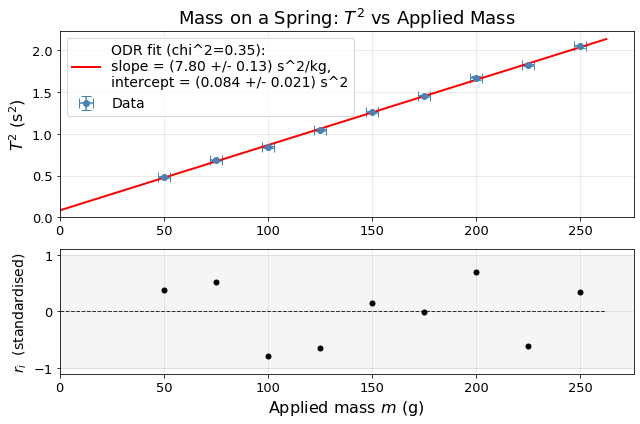

In [6]:
chi2_odr = res_full.sum_square / (len(y) - 2)

r_full = (-np.sign(res_full.eps)
          * np.sqrt((res_full.eps / dy)**2
                  + (res_full.delta / dx)**2))

fig, ax = plt.subplots(2, 1, figsize=(9,6),
                       gridspec_kw={'height_ratios': [3, 2]})

ax[0].errorbar(x * 1e3, y, xerr=dx * 1e3, yerr=dy,
               fmt='o', color='steelblue', capsize=5, label='Data')

x_line = np.linspace(0, x.max() * 1.05, 100)
ax[0].plot(x_line * 1e3, slope_full * x_line + intercept_full, 'r-', lw=2,
           label=f'ODR fit (chi^2={chi2_odr:.2f}):'
           f'\nslope = ({slope_full:.2f} +/- {dslope_full:.2f}) s^2/kg,'
           f'\nintercept = ({intercept_full:.3f} +/- {dintercept_full:.3f}) s^2')

ax[0].set_ylabel(r'$T^2$ (s$^2$)', fontsize=16)
ax[0].set_title(r'Mass on a Spring: $T^2$ vs Applied Mass', fontsize=18)
ax[0].legend(fontsize=14)
ax[0].tick_params(labelsize=13)
ax[0].set_xlim(0, None)
ax[0].set_ylim(0, None)
ax[0].grid(True, alpha=0.3)

ax[1].plot(x * 1e3, r_full, '.', color='k', markersize=10)
ax[1].hlines(0, 0, x.max() * 1e3 * 1.05,
             lw=1, alpha=0.8, color='k', linestyle='--')
ax[1].axhspan(-1, 1, alpha=0.08, color='gray')
ax[1].set_xlabel(r'Applied mass $m$ (g)', fontsize=16)
ax[1].set_ylabel(r'$r_i$  (standardised)', fontsize=14)
ax[1].tick_params(labelsize=13)
ax[1].set_xlim(0, None)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.7 Step 2 - Uncertainty Budget

For each source, double its uncertainty and apply:

$$\text{impact} = \sqrt{\frac{\delta k_{\text{doubled}}^2 - \delta k_{\text{full}}^2}{3}}$$

Per-point sources ($\delta T$, $\delta m$) require a new fit with doubled error bars. The spring mass only enters through the $\alpha$ formula, so doubling $\delta m_s$ just means calling `dalpha_total` with `2*dm_spring` — no refit.

In [7]:
# refit with each per-point source doubled
r_2T = fit_spring(x, y, dx,   2*dy)
r_2m = fit_spring(x, y, 2*dx, dy)
dk_2T, res_2T = r_2T[1], r_2T[6]
dk_2m, res_2m = r_2m[1], r_2m[6]

# k impacts
impact_T_k = np.sqrt((dk_2T**2 - dk_full**2) / 3)
impact_m_k = np.sqrt((dk_2m**2 - dk_full**2) / 3)

print('k budget')
print(f' • period scatter:  {impact_T_k:.4f} N/m')
print(f' • applied mass:    {impact_m_k:.4f} N/m')
print()

# alpha impacts (spring mass: no refit, just doubled dms)
da_2T  = dalpha_total(res_2T,  m_spring,    dm_spring)
da_2m  = dalpha_total(res_2m,  m_spring,    dm_spring)
da_2ms = dalpha_total(res_full, m_spring, 2*dm_spring)

impact_T_alpha  = np.sqrt((da_2T**2  - dalpha_full**2) / 3)
impact_m_alpha  = np.sqrt((da_2m**2  - dalpha_full**2) / 3)
impact_ms_alpha = np.sqrt((da_2ms**2 - dalpha_full**2) / 3)

print('alpha budget')
print(f' • period scatter:  {impact_T_alpha:.4f}')
print(f' • applied mass:    {impact_m_alpha:.4f}')
print(f' • spring mass:     {impact_ms_alpha:.4f}')

k budget
 • period scatter:  0.0413 N/m
 • applied mass:    0.0758 N/m

alpha budget
 • period scatter:  0.0384
 • applied mass:    0.0865
 • spring mass:     0.0347


### 3.8 Impact plots

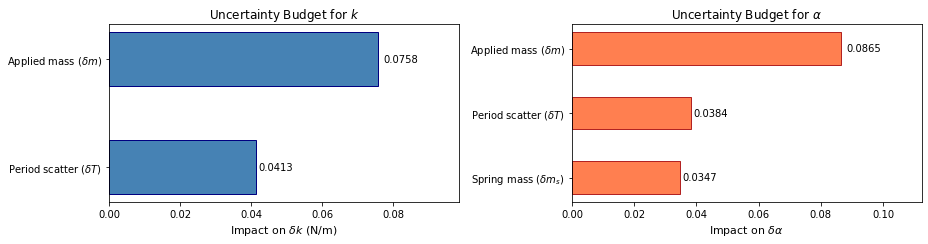

In [8]:
sources_k = [r'Period scatter ($\delta T$)',
             r'Applied mass ($\delta m$)']
impacts_k = [impact_T_k, impact_m_k]
order_k   = np.argsort(impacts_k)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

ax = axes[0]
bars = ax.barh([sources_k[i] for i in order_k],
               [impacts_k[i] for i in order_k],
               color='steelblue', edgecolor='navy', height=0.5)
ax.set_xlim(0, max(impacts_k) * 1.3)
for bar, val in zip(bars, [impacts_k[i] for i in order_k]):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel(r'Impact on $\delta k$ (N/m)', fontsize=11)
ax.set_title(r'Uncertainty Budget for $k$', fontsize=12)
ax.invert_yaxis()

sources_a = [r'Period scatter ($\delta T$)',
             r'Applied mass ($\delta m$)',
             r'Spring mass ($\delta m_s$)']
impacts_a = [impact_T_alpha, impact_m_alpha, impact_ms_alpha]
order_a   = np.argsort(impacts_a)[::-1]

ax = axes[1]
bars = ax.barh([sources_a[i] for i in order_a],
               [impacts_a[i] for i in order_a],
               color='coral', edgecolor='firebrick', height=0.5)
ax.set_xlim(0, max(impacts_a) * 1.3)
for bar, val in zip(bars, [impacts_a[i] for i in order_a]):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel(r'Impact on $\delta\alpha$', fontsize=11)
ax.set_title(r'Uncertainty Budget for $\alpha$', fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 3.9 Consistency checks

The impacts should add in quadrature and roughly match the full fit uncertainties:

$$\sqrt{\text{impact}_T^2 + \text{impact}_m^2} \approx \delta k_{\text{full}} \qquad \sqrt{\text{impact}_{T,\alpha}^2 + \text{impact}_{m,\alpha}^2 + \text{impact}_{ms,\alpha}^2} \approx \delta\alpha_{\text{full}}$$

A ratio near 1 means the identified sources account for the full uncertainty. A ratio noticeably above 1 might mean the sources are correlated, or that one has been missed.

In [9]:
quad_k = np.sqrt(impact_T_k**2 + impact_m_k**2)
quad_a = np.sqrt(impact_T_alpha**2 + impact_m_alpha**2 + impact_ms_alpha**2)

print('k budget')
print(f' • quadrature sum = {quad_k:.4f} N/m')
print(f' • δk (full fit)  = {dk_full:.4f} N/m')
print(f' • ratio          = {quad_k / dk_full:.3f}')
print()
print('alpha budget')
print(f' • quadrature sum = {quad_a:.4f}')
print(f' • δα (full fit)  = {dalpha_full:.4f}')
print(f' • ratio          = {quad_a / dalpha_full:.3f}')

k budget
 • quadrature sum = 0.0863 N/m
 • δk (full fit)  = 0.0873 N/m
 • ratio          = 0.989

alpha budget
 • quadrature sum = 0.1008
 • δα (full fit)  = 0.1014
 • ratio          = 0.993


**Discussion:** We see here that these ratios are quite close to 1 so we seem to have a complete set of independent uncertainties.

## 4. Interpreting your uncertainty budget

The longest bar from your impact plot identifies the first place to focus if you want to reduce the overall uncertainty of your final result. Short bars on your impact plot represent smaller contributions to the total uncertianty, meaning that improving these will not help in a meaningful way until you have first improved the precision of the larger impact sources of uncertainty.

Additionally, the quadrature sum of all impacts should roughly match the full fit uncertainty. A large discrepancy might mean the sources are not truly independent, or that you have missed one.

## Acknowledgements

This document was developed with support from Claude, primarily related to syntax and formatting